<a href="https://colab.research.google.com/github/Luke-687/Simulating-Chemotaxis--Q-learning-and-Heuristic-/blob/main/Chemotaxis_Heuristic_(Heat_Map).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import math
import random
import matplotlib.pyplot as plt

In [ ]:
#s is for the steepness of the gradient
def defineScene(xS,yS, s):
  x = []
  y = []
  color = []
  gradient = []
  reward = []
  #Consider 20x20 grid, source of chemical at (15,15) with a decrease in alpha by r^2
  for i in range (0,xS+1):
    for j in range (0,yS+1):
      x.append(j)
      y.append(i)
      #distance based calculations:
      distance = math.sqrt((i-(xS/2))**2+(j-(yS/2))**2)
      if(distance <= 5):
        color.append("green")
        if(not distance<=1):
          gradient.append(1/(distance**s))
          reward.append(10/(distance**s))
        else:
          gradient.append(1)
          reward.append(50)
      else:
        color.append("green")
        gradient.append(0)
        reward.append(-50)
  return x, y, gradient, reward

def calculate_velocity(posX, posY, rewards):
  posX = int(posX)
  posY = int(posY)
  currentReward = rewards[posX+posY*20]
  if(currentReward<0):
    velocity = 4
  else:
    velocity = 1.5/currentReward
  if(velocity>=4):
    velocity = 4
  return velocity

def calculate_direction(currentX, currentY, pastR, currentR, currentDirection, p):

  #Define the basic change in the direction
  change=0
  currentPos = math.sqrt((currentX-9.5)**2 + (currentY-9.5)**2)

  if(not currentR==0 and not pastR==0):

    if(currentPos<=5):

      change = 360*(abs(pastR/currentR)**0.8)*((random.choice([-1,1])))
      # print("Inside: " + str(change))

    else:

      if(pastR>currentR):

        if(abs(pastR)<abs(currentR)):
          change = (180-180*(abs((pastR)/(currentR))**p))*((random.choice([-1,1,-1,-1,-1])))
          # print("Outside: " + str(change))

        else:
          change = (180-180*(abs((currentR)/(pastR))**p))*((random.choice([-1,1,-1,-1,-1])))
          # print("Outside: " + str(change))


  newDirection = (currentDirection+change)%360
  return (newDirection)

def simulate (alpha, gamma, xS, yS,steps, steep):
  #Define the initial parameters
  velocity = 4
  direction = random.randint(10,80)
  #Starting position is some (x,y) outside of gradient
  currentX = 0
  currentY = 0
  stepsToBeMade=steps
  xG, yG, gradient, reward = defineScene(xS, yS, steep)
  #This works as an adjustment to the direction recalculation
  p=0.59
  #This works as an adjustment to the alpha and gamma in updated rewards
  mult = 3.75

  #Track x,y pos
  x=[]
  y=[]

  pastReward = 0
  for i in range(0, stepsToBeMade):
    #Enter and calculate reward of values which are about to be moved on from
    currentX = max(0, min(currentX, 19))
    currentY = max(0, min(currentY, 19))
    x.append(currentX)
    y.append(currentY)

    #Find new position, and new current reward
    brownian = brownianMotion()
    changeX = velocity * math.cos(direction*math.pi/180) + brownian[0]
    changeY = velocity * math.sin(direction*math.pi/180) + brownian[1]
    currentX = x[-1] + changeX
    currentY = y[-1] + changeY
    currentX = max(0, min(currentX, 19))
    currentY = max(0, min(currentY, 19))
    currentReward = pastReward + mult*alpha*(reward[int(currentX+currentY*20)]+mult*gamma*(reward[int(currentX+currentY*20)]-pastReward))

    #Redifine velocity and direction for next steps
    velocity = calculate_velocity(int(currentX), int(currentY), reward)
    direction = calculate_direction(currentX, currentY, pastReward, currentReward, direction, p)
    pastReward = currentReward
  return x,y

def brownianMotion():
  result = [0,0]
  xChange = random.random()/4
  yChange = random.random()/4
  for i in range(10):
    xChange+= random.random()/100 * (-1**(random.randint(1,2)))
    yChange+= random.random()/100 * (-1**(random.randint(1,2)))
  result = [xChange, yChange]
  return result

In [ ]:
#Optimal parameters
alpha = 0.9
gamma = 0.9

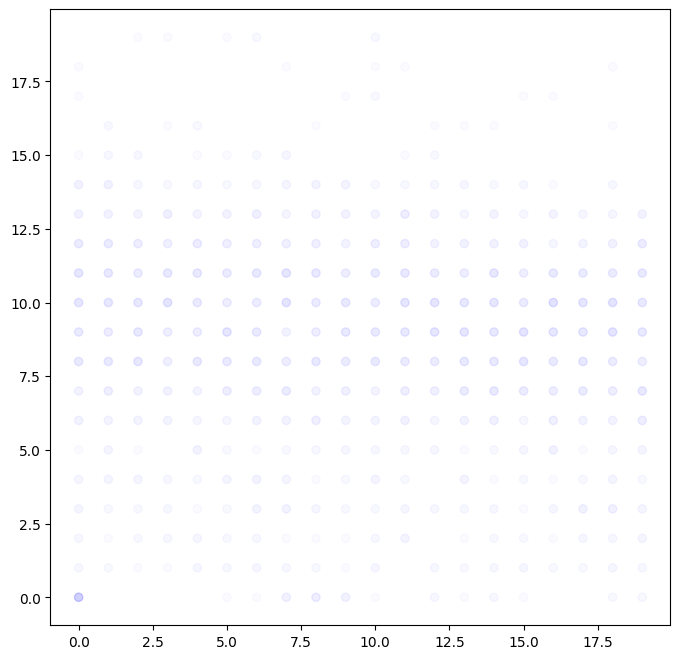

In [ ]:
#Run the simulation of chemotaxis 100 times with 500 steps of traning for the model of each simulation and calculate the heat map based up stepsAtSpot/TotalSteps, plugging in that value into an alpha equation
heatVals = [] #To be plugged into alpha variable in final visualization
xGraph = []
yGraph = []
for y in range(20):
  for x in range(20):
    yGraph.append(y)
    xGraph.append(x)
    heatVals.append(0)
for sim in range(100):
  xSim, ySim = simulate(alpha, gamma, 19, 19, 30, 0.75)
  for pos in range(len(xSim)):
    heatVals[int(xSim[pos])+int(ySim[pos]*20)] += 1/3000

#Make trends more visible, as the alpha values are too small to truly pick up on anything:
for i in range(len(heatVals)):
  heatVals[i] = (heatVals[i])**0.5

# Plot each point individually with varying alpha
plt.figure(figsize=(8, 8))
plt.scatter(xGraph, yGraph, c="blue", alpha=heatVals)